In [5]:
%pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 9.2 MB/s eta 0:00:000m eta 0:00:010:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 8.4 MB/s eta 0:00:000m eta 0:00:010:012
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression #, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score

import statsmodels.api as sm

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from pygam import LinearGAM, s, f, l


from dmba import classificationSummary

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
try:
    import common
    DATA = common.dataDirectory()
except:
    DATA = '/home/gadamurrr/Desktop/practical-statistics-for-data-scientists/data/'

LOAN3000_CSV = DATA + 'loan3000.csv'
LOAN_DATA_CSV = DATA + 'loan_data.csv.gz'
FULL_TRAIN_SET_CSV = DATA + 'full_train_set.csv.gz'

# Наивный Байес

In [3]:
loan_data = pd.read_csv(LOAN_DATA_CSV)

# конвертируем в категориальные
loan_data.outcome = loan_data.outcome.astype("category")
loan_data.outcome.cat.reorder_categories(["paid off", "default"])
loan_data.purpose_ = loan_data.purpose_.astype("category")
loan_data.home_ = loan_data.home_.astype("category")
loan_data.emp_len_ = loan_data.emp_len_.astype("category")

predictors = ["purpose_", "home_", "emp_len_"]
outcome = "outcome"

X = pd.get_dummies(loan_data[predictors], prefix="", prefix_sep="", dtype=int)
y = loan_data[outcome]

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model = MultinomialNB(alpha=1e-10, fit_prior=False)

naive_model.fit(X, y)

new_loan = X.loc[146:146, :]
print("предсказанный класс: ", naive_model.predict(new_loan)[0])

probabilities = pd.DataFrame(naive_model.predict_proba(new_loan), columns=naive_model.classes_)
probabilities

предсказанный класс:  default


,default,paid off
0,0.653699,0.346301


## scikit-learn:
### predict - возвращает предсказанный класс
### predict_proba - возвращает вероятности классов

### затем используется скользящий порог отсечения /для конвератации балов склонности в решение. Общий подход таков:
1. Установить пороговую вероятность для интересующего класса, выше которой мы рассматриваем запись как принадлежащую этому классу
2. Оценить вероятность того, что запись принадлежит интересующему классу
3. Если эта вероятность выше пороговой вероятности, то назначить новую запись интересующему классу

# Дискриминантный анализ

In [4]:
loan3000 = pd.read_csv(LOAN3000_CSV)
loan3000.outcome = loan3000.outcome.astype('category')

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
print(pd.DataFrame(loan_lda.scalings_, index=X.columns))

                          0
borrower_score     7.175839
payment_inc_ratio -0.099676


In [5]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


Предсказание линейным дискримин.анализом невыплаты ссуды с использованием двух переменных: балла кредитоспособности заемщикак и отношения платежей к доходу

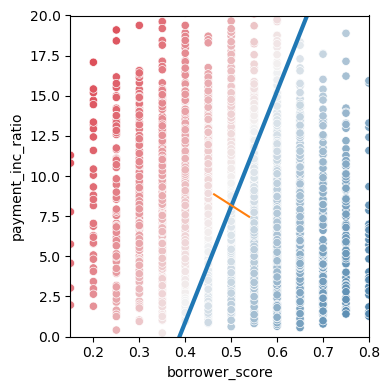

In [6]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)
lda_df.head()

fig, ax = plt.subplots(figsize=(4, 4))
g = sns.scatterplot(x='borrower_score', y='payment_inc_ratio',
                    hue='default', data=lda_df, 
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)

ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()

точки слева от диагональной прямой предсказ-ся как невыплата

используя веса дискримин.функции линейный дискримин.анализ разбивает предсказательное пространство на 2 участка

предсказания, которые расположены от линии намного дальше в обоих направлениях имеют более высокий уровень доверия

# Логистическая регрессия

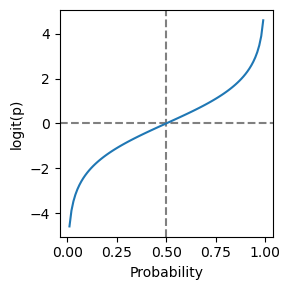

In [7]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    'p': p,
    'logit': np.log(p / (1 - p)),
    'odds': p / (1 - p),
})

fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0.5, color='grey', linestyle='--')
ax.plot(df['p'], df['logit'])
ax.set_xlabel('Probability')
ax.set_ylabel('logit(p)')

plt.tight_layout()
plt.show()

График логит функции которая отображает вероятность в шкалу, подходящую для линейной модели

# Логистическая регрессия и ОЛМ

In [8]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = loan_data[outcome] # .cat.categories

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(X, y)

print('intercept ', logit_reg.intercept_[0])
print('classes', logit_reg.classes_)
pd.DataFrame({'coeff': logit_reg.coef_[0]}, 
             index=X.columns)

intercept  -1.6378909391299383
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079739
borrower_score,4.612184
debt_consolidation,-0.249414
home_improvement,-0.407734
major_purchase,-0.229709
medical,-0.510744
other,-0.620800
small_business,-1.214936
OWN,-0.048211
RENT,-0.157288


In [9]:
print(loan_data['purpose_'].cat.categories)
print(loan_data['home_'].cat.categories)
print(loan_data['emp_len_'].cat.categories)

Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='object')
Index(['MORTGAGE', 'OWN', 'RENT'], dtype='object')
Index([' < 1 Year', ' > 1 Year'], dtype='object')


Нет в книге: Если у вас есть переменная признака или результата, которая является порядковой, используйте scikit-learn OrdinalEncoder, чтобы заменить категории (здесь, 'paid off' и 'default') числами. В приведенном ниже коде мы заменяем 'paid off' на 0, а 'default' на 1. Это меняет порядок предсказанных классов, и, как следствие, коэффициенты будут обратными.


In [10]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['paid off', 'default']])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]}, 
             index=X.columns)

intercept  1.6378908330620763
classes [0. 1.]


,coeff
payment_inc_ratio,0.079739
borrower_score,-4.612183
debt_consolidation,0.249414
home_improvement,0.407734
major_purchase,0.229710
medical,0.510744
other,0.620800
small_business,1.214936
OWN,0.048211
RENT,0.157288


# Предсказанные значения из логистичсекой регрессии

In [11]:
pred = pd.DataFrame(logit_reg.predict_log_proba(X), columns=logit_reg.classes_)
pred.describe()

,default,paid off
count,45342.000000,45342.000000
mean,-0.757872,-0.760434
std,0.378093,0.390456
min,-2.769376,-3.538593
25%,-0.985739,-0.977207
50%,-0.697406,-0.688907
75%,-0.472183,-0.467069
max,-0.029485,-0.064753


In [12]:
pred = pd.DataFrame(logit_reg.predict_proba(X), columns=logit_reg.classes_)
pred.describe()

,default,paid off
count,45342.000000,45342.000000
mean,0.500000,0.500000
std,0.167354,0.167354
min,0.062701,0.029054
25%,0.373163,0.376361
50%,0.497875,0.502125
75%,0.623639,0.626837
max,0.970946,0.937299


# Интерпретирование коэффициентов и отношений перевесов

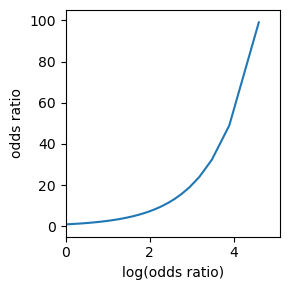

In [13]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df['logit'], df['odds'])
ax.set_xlabel('log(odds ratio)')
ax.set_ylabel('odds ratio')
ax.set_xlim(0, 5.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

Связь между отношением перевесов и логарифмом отношения перевесов

# Оценивание классификационных моделей

In [14]:
# матрица путаницы

In [15]:
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == "default"
true_y = y == "default"

true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame(
    [[np.sum(true_pos), np.sum(false_neg)], [np.sum(false_pos), np.sum(true_neg)]],
    index=["Y = default", "Y = paid off"],
    columns=["Yhat = default", "Yhat = paid off"],
)

conf_mat

,Yhat = default,Yhat = paid off
Y = default,14337,8334
Y = paid off,8149,14522


Пакет _dmba_ содержит функцию `classificationSummary`, которая выводит матрицу неточностей и точность для модели классификации.

In [16]:
classificationSummary(y, logit_reg.predict(X), 
                      class_names=logit_reg.classes_)

Confusion Matrix (Accuracy 0.6365)

         Prediction
  Actual  default paid off
 default    14337     8334
paid off     8149    14522


## Прецизионность(точность), полнота и специфичность
Функция _scikit-learn_ `precision_recall_fscore_support` возвращает
точность, полноту, fbeta_score и поддержку.

In [19]:
conf_mat = confusion_matrix(y, logit_reg.predict(X))

# По формулам
print("Прецизионность: ", conf_mat[0, 0] / sum(conf_mat[:, 0]))
print("Полнота: ", conf_mat[0, 0] / sum(conf_mat[0, :]))
print("Специфичность: ", conf_mat[1, 1] / sum(conf_mat[1, :]))

Прецизионность:  0.6375967268522637
Полнота:  0.6323938070662961
Специфичность:  0.640554011733051


In [18]:
precision_recall_fscore_support(y, logit_reg.predict(X), 
                                labels=['default', 'paid off'])

(array([0.63759673, 0.63536927]),
 array([0.63239381, 0.64055401]),
 array([0.63498461, 0.63795111]),
 array([22671, 22671]))

# ROC кривая

Функция `roc_curve` в _Scikit-learn_ вычисляет всю информацию, необходимую для построения ROC-кривой.

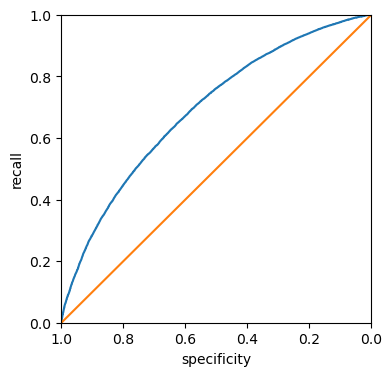

In [20]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0], 
                                pos_label="default")

roc_df = pd.DataFrame({"recall": tpr, "specificity": 1 - fpr})

ax = roc_df.plot(x="specificity", y="recall", figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1))
ax.set_xlabel("specificity")
ax.set_ylabel("recall")

plt.show()


## AUC
Точность можно легко рассчитать с помощью функции _scikit-learn_ `accuracy_score`.

In [21]:
np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity))

0.691710717463757

In [22]:
roc_auc_score([1 if yi == "default" else 0 for yi in y], logit_reg.predict_proba(X)[:, 0])

0.691710795288669

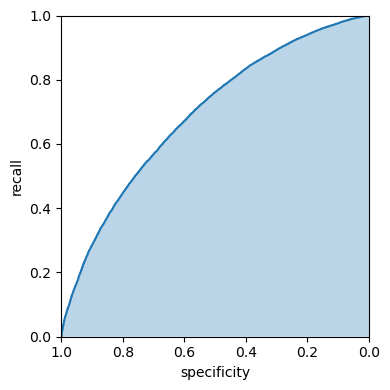

In [23]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:,0], 
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
# ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)


plt.tight_layout()
plt.show()

# Стратегии для несбалансированных данных

In [24]:
full_train_set = pd.read_csv(FULL_TRAIN_SET_CSV)
full_train_set.shape

(119987, 19)

In [25]:
print('процент невыплаченных ссуд: ', 
print(      100 * np.mean(full_train_set.outcome == 'default')))

18.894546909248504
процент невыплаченных ссуд:  None


In [29]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
full_model.fit(X, y)
print('процент ссуд, предсказанных как невыплаченные: ', 
print(      100 * np.mean(full_model.predict(X) == 'default')))

1.0067757340378543
процент ссуд, предсказанных как невыплаченные:  None


In [30]:
(np.mean(full_train_set.outcome == 'default') / 
 np.mean(full_model.predict(X) == 'default'))

18.767384105960264

# Генерация данных

In [32]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print('процент невыплаченных ссуд (повторная выборка SMOTE):', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver="liblinear")
full_model.fit(X_resampled, y_resampled)
print('процент ссуд, предсказанных как невыплаченные (SMOTE):', 
      100 * np.mean(full_model.predict(X) == 'default'))

X_resampled, y_resampled = ADASYN().fit_resample(X, y)
print('процент невыплаченных ссуд (повторная выборка ADASYN):', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver="liblinear")
full_model.fit(X_resampled, y_resampled)
print('Процент ссуд, предсказанных как невыплаченные (ADASYN):', 
print(      100 * np.mean(full_model.predict(X) == 'default')))

процент невыплаченных ссуд (повторная выборка SMOTE): 50.0
процент ссуд, предсказанных как невыплаченные (SMOTE): 29.419853817496893
процент невыплаченных ссуд (повторная выборка ADASYN): 48.56040383751355
27.281288806287346
Процент ссуд, предсказанных как невыплаченные (ADASYN): None


# Разведывание предсказаний

In [33]:
loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', 
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)

logit_reg = LogisticRegression(penalty="l2", solver='liblinear')
logit_reg.fit(X, y)


## model
gam = LinearGAM(s(0) + s(1))
print(gam.gridsearch(X.values, [1 if yi == 'default' else 0 for yi in y]))

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + intercept, 
   tol=0.0001, verbose=False)


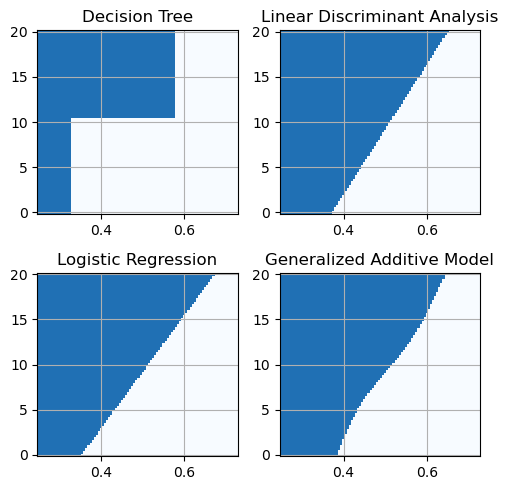

In [34]:
models = {
    'Decision Tree': loan_tree,
    'Linear Discriminant Analysis': loan_lda,
    'Logistic Regression': logit_reg,
    'Generalized Additive Model': gam,
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))

xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
X = pd.DataFrame({
    'borrower_score': xx.ravel(),
    'payment_inc_ratio': yy.ravel(),
})

boundary = {}

for n, (title, model) in enumerate(models.items()):
    ax = axes[n // 2, n % 2]
    predict = model.predict(X)
    if 'Generalized' in title:
        Z = np.array([1 if z > 0.5 else 0 for z in predict])
    else:
        
        Z = np.array([1 if z == 'default' else 0 for z in predict])
    Z = Z.reshape(xx.shape)
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)]
    boundary[title][Z[-1,:] == 0] = yvalues[-1]

    c = ax.pcolormesh(xx, yy, Z, cmap='Blues', vmin=0.1, vmax=1.3, shading='auto')
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()

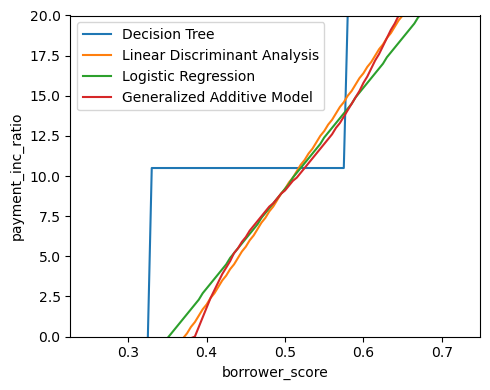

In [35]:
boundary['borrower_score'] = xvalues
boundaries = pd.DataFrame(boundary)

fig, ax = plt.subplots(figsize=(5, 4))
boundaries.plot(x='borrower_score', ax=ax)
ax.set_ylabel('payment_inc_ratio')
ax.set_ylim(0, 20)


plt.tight_layout()
plt.show()